In [17]:
# made by Gibeom LEE, HI LAB
# csv 파일 시계열 파일을 이산푸리에 변환을 통하여 아웃풋을 내놓습니다.

In [18]:
# 1. 필요한 라이브러리 임포트
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq


=== TENG w Cp.csv ===
샘플 개수: 41250
샘플링 간격(중앙값): 0.000040000 s
샘플링 주파수: 25000.000 Hz

[상위 10개 피크] (소수점 셋째자리)
01) 7.879 Hz  |  Amp: 7.253
02) 3.636 Hz  |  Amp: 4.256
03) 12.121 Hz  |  Amp: 3.815
04) 15.758 Hz  |  Amp: 2.804
05) 31.515 Hz  |  Amp: 1.387
06) 27.879 Hz  |  Amp: 1.324
07) 23.636 Hz  |  Amp: 1.031
08) 35.758 Hz  |  Amp: 0.928
09) 20.000 Hz  |  Amp: 0.683
10) 51.515 Hz  |  Amp: 0.577

가장 큰 피크: 7.879 Hz (Amp: 7.253)


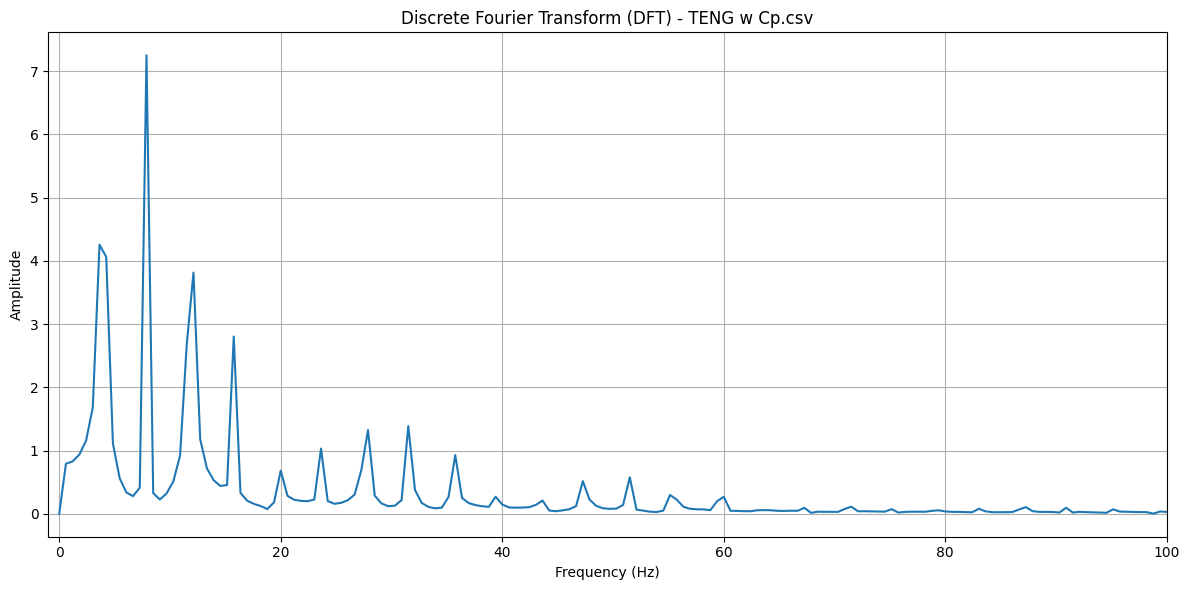


=== TENG wo Cp.csv ===
샘플 개수: 42440
샘플링 간격(중앙값): 0.000040000 s
샘플링 주파수: 25000.000 Hz

[상위 10개 피크] (소수점 셋째자리)
01) 11.781 Hz  |  Amp: 10.429
02) 7.658 Hz  |  Amp: 8.427
03) 15.905 Hz  |  Amp: 7.314
04) 4.123 Hz  |  Amp: 6.538
05) 27.686 Hz  |  Amp: 5.575
06) 31.810 Hz  |  Amp: 5.226
07) 35.344 Hz  |  Amp: 3.075
08) 51.249 Hz  |  Amp: 2.594
09) 23.563 Hz  |  Amp: 2.588
10) 20.028 Hz  |  Amp: 2.193

가장 큰 피크: 11.781 Hz (Amp: 10.429)


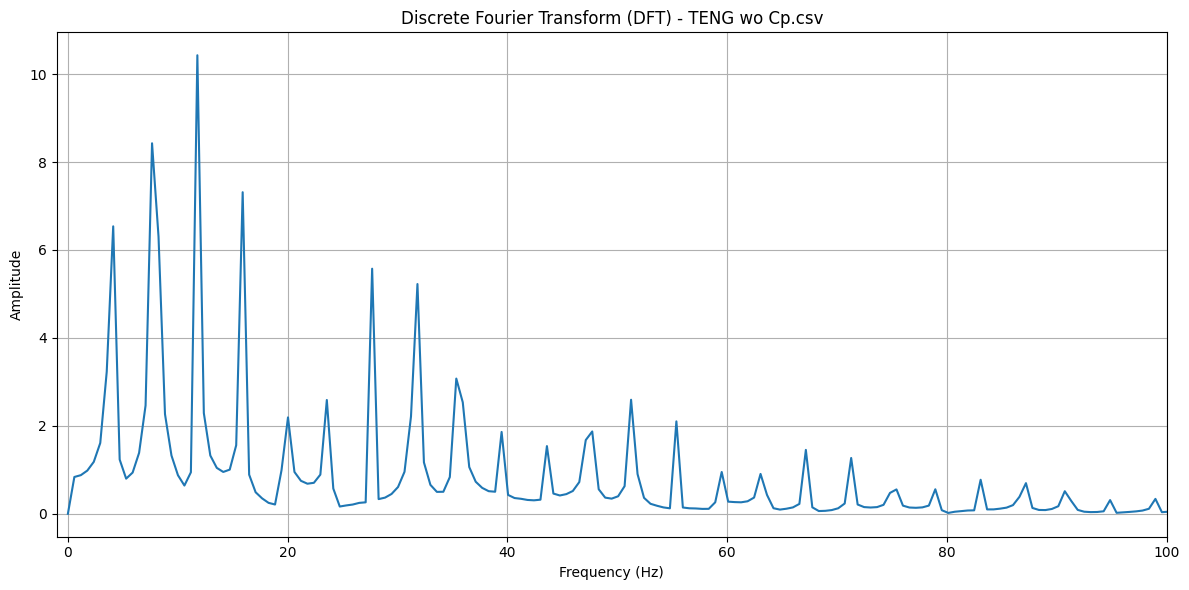

In [19]:
# -------------------------------
# 설정값
folder_path = r"C:\Users\user\Desktop\Gibeom\HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260302_bending 실험 및 기생캡 차이\csv파일\Cp 분석"

# 관심 주파수 범위(그래프/피크 출력 범위)
fmin_plot, fmax_plot = -1, 100     # 그래프 x축 범위
fmin_peak, fmax_peak = 0, 100      # 피크 탐색 범위(DC 제외하므로 0부터)

# 출력할 피크 개수
top_k_peaks = 10

# 피크 검출 파라미터(필요 시 조정)
# prominence가 너무 크면 피크가 적게 잡히고, 너무 작으면 잡음 피크가 많아집니다.
peak_prominence = None  # 예: 0.05
peak_height = None      # 예: 0.1
peak_distance_hz = None # 예: 0.5  (Hz 단위로 최소 간격 주고 싶으면 아래에서 샘플로 변환)


# -------------------------------
# CSV 파일 목록 가져오기
csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".csv")]
csv_files.sort()

if not csv_files:
    raise FileNotFoundError(f"폴더에 CSV 파일이 없습니다: {folder_path}")

# -------------------------------
# 파일별 FFT 분석
for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)

    try:
        # 1) CSV 로드
        df = pd.read_csv(file_path)

        # 2) 시간/신호 추출 (첫 2개 열 사용)
        time = df.iloc[:, 0].to_numpy(dtype=float)
        signal = df.iloc[:, 1].to_numpy(dtype=float)

        # 3) 샘플링 정보
        N = len(signal)
        if N < 4:
            raise ValueError("데이터 길이가 너무 짧습니다 (N < 4).")

        # 시간축이 균일 샘플링인지 간단 체크
        dt = np.diff(time)
        T = np.median(dt)  # 중앙값 사용(미세 오차 대비)
        fs = 1.0 / T

        print(f"\n=== {file_name} ===")
        print(f"샘플 개수: {N}")
        print(f"샘플링 간격(중앙값): {T:.9f} s")
        print(f"샘플링 주파수: {fs:.3f} Hz")

        # 4) FFT
        yf = fft(signal)
        xf = fftfreq(N, T)[:N // 2]          # 양수 주파수
        amp = (2.0 / N) * np.abs(yf[:N // 2])  # 진폭 스펙트럼

        # DC 성분 제외
        if len(amp) > 0:
            amp[0] = 0.0

        # 5) 피크 탐색 범위 마스크
        mask = (xf >= fmin_peak) & (xf <= fmax_peak)
        xf_m = xf[mask]
        amp_m = amp[mask]

        if len(xf_m) < 3:
            raise ValueError("피크 탐색에 사용할 주파수 포인트가 너무 적습니다.")

        # 6) find_peaks 파라미터 (거리 Hz -> 샘플 인덱스 변환)
        kwargs = {}
        if peak_prominence is not None:
            kwargs["prominence"] = peak_prominence
        if peak_height is not None:
            kwargs["height"] = peak_height
        if peak_distance_hz is not None:
            # 주파수 해상도 df = fs/N
            dfreq = fs / N
            kwargs["distance"] = max(1, int(round(peak_distance_hz / dfreq)))

        peaks, props = find_peaks(amp_m, **kwargs)

        # 7) 피크 정렬 (진폭 큰 순)
        if len(peaks) == 0:
            print("⚠️ 피크가 검출되지 않았습니다. (prominence/height 조정 필요)")
        else:
            # peaks는 amp_m 기준 인덱스
            peaks_sorted = sorted(peaks, key=lambda i: amp_m[i], reverse=True)

            print(f"\n[상위 {min(top_k_peaks, len(peaks_sorted))}개 피크] (소수점 셋째자리)")
            for rank, i in enumerate(peaks_sorted[:top_k_peaks], start=1):
                print(f"{rank:02d}) {xf_m[i]:.3f} Hz  |  Amp: {amp_m[i]:.3f}")

            # 가장 큰 피크 1개
            i0 = peaks_sorted[0]
            print(f"\n가장 큰 피크: {xf_m[i0]:.3f} Hz (Amp: {amp_m[i0]:.3f})")

        # 8) 그래프
        plt.figure(figsize=(12, 6))
        plt.plot(xf, amp)
        plt.title(f"Discrete Fourier Transform (DFT) - {file_name}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Amplitude")
        plt.xlim(fmin_plot, fmax_plot)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️ {file_name} 처리 중 오류 발생: {e}")